# Notebook 5: Insights & Evaluation
## AI-Powered Job Market Intelligence — Sri Lanka

### What we do here:
- Salary trend analysis
- Skill gap analysis
- Career recommendations
- Final visualizations
- Project summary report

Input  → data/processed/model_results.csv
Output → outputs/ (charts and report)

In [1]:
# ── IMPORTS ──────────────────────────────────

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  # For complex chart layouts
import seaborn as sns
from collections import Counter

# Set chart style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
# ── SET PATHS ────────────────────────────────

BASE_PATH            = 'D:/Sinali/projects/job_market_intelligence_platform'
PROCESSED_DATA_PATH  = f'{BASE_PATH}/data/processed'
OUTPUT_PATH          = f'{BASE_PATH}/outputs'

os.makedirs(OUTPUT_PATH, exist_ok=True)

# ── LOAD DATA ────────────────────────────────

print("📂 Loading model results...")

df = pd.read_csv(f'{PROCESSED_DATA_PATH}/model_results.csv')

# Fill missing values
df['all_skills_str'] = df['all_skills_str'].fillna('')
df['salary']         = df['salary'].fillna('Not Specified')
df['location']       = df['location'].fillna('Unknown')

print(f"✅ Data loaded!")
print(f"📊 Rows    : {len(df)}")
print(f"📊 Columns : {len(df.columns)}")
print(f"\n📋 Cluster distribution:")
print(df['cluster_name'].value_counts().to_string())
print(f"\n📋 Topic distribution:")
print(df['dominant_topic_name'].value_counts().to_string())

📂 Loading model results...
✅ Data loaded!
📊 Rows    : 4301
📊 Columns : 16

📋 Cluster distribution:
cluster_name
Marketing & Architecture    1815
Design & UI/UX               820
Data & Analytics             557
Network & Security           480
Software Development         403
Database & Systems           226

📋 Topic distribution:
dominant_topic_name
UI/UX Design                 1007
Network & Security            877
Engineering & Systems         689
Application Development       624
Data & Business Analytics     623
Testing & Performance         481


💰 SALARY ANALYSIS:
   Jobs with salary data : 4301
   Average salary        : $82,513
   Highest salary        : $97,500
   Lowest salary         : $67,500

💰 AVERAGE SALARY BY JOB CLUSTER:
   Data & Analytics               : $82,959
   Network & Security             : $82,665
   Marketing & Architecture       : $82,563
   Design & UI/UX                 : $82,323
   Software Development           : $82,129
   Database & Systems             : $82,058


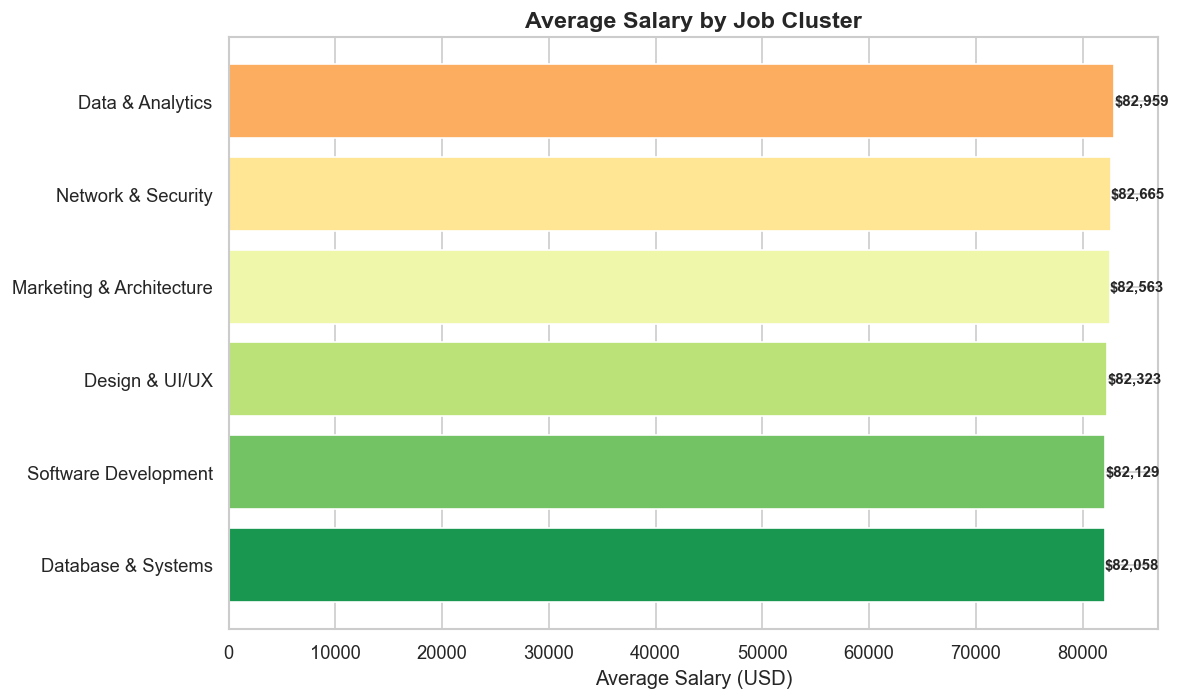


✅ Chart saved to: D:/Sinali/projects/job_market_intelligence_platform/outputs/salary_by_cluster.png


In [5]:
# ── SALARY ANALYSIS ──────────────────────────

def extract_salary(salary_str):
    """
    Extracts average salary from string
    Example: '59K-99K' → 79000
    """
    if pd.isna(salary_str) or salary_str == 'Not Specified':
        return np.nan
    
    # Find all numbers in salary string
    numbers = re.findall(r'\d+', str(salary_str))
    
    if len(numbers) >= 2:
        min_sal = int(numbers[0]) * 1000  # Convert K to full number
        max_sal = int(numbers[1]) * 1000
        return (min_sal + max_sal) / 2    # Return average
    return np.nan

import re

# Apply salary extraction
df['salary_avg'] = df['salary'].apply(extract_salary)

# Show salary stats
print("💰 SALARY ANALYSIS:")
print("=" * 45)
print(f"   Jobs with salary data : {df['salary_avg'].notna().sum()}")
print(f"   Average salary        : ${df['salary_avg'].mean():,.0f}")
print(f"   Highest salary        : ${df['salary_avg'].max():,.0f}")
print(f"   Lowest salary         : ${df['salary_avg'].min():,.0f}")

# Average salary per cluster
print(f"\n💰 AVERAGE SALARY BY JOB CLUSTER:")
print("=" * 45)
salary_by_cluster = df.groupby('cluster_name')['salary_avg'].mean().sort_values(ascending=False)
for cluster, salary in salary_by_cluster.items():
    print(f"   {cluster:<30} : ${salary:,.0f}")

# ── VISUALIZE ────────────────────────────────
plt.figure(figsize=(10, 6))

colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(salary_by_cluster)))

bars = plt.barh(
    salary_by_cluster.index[::-1],
    salary_by_cluster.values[::-1],
    color=colors[::-1]
)

for bar, val in zip(bars, salary_by_cluster.values[::-1]):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f'${val:,.0f}',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('Average Salary by Job Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Average Salary (USD)', fontsize=12)
plt.tight_layout()

chart_path = f'{OUTPUT_PATH}/salary_by_cluster.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Chart saved to: {chart_path}")

In [6]:
# ── SKILL GAP ANALYSIS ───────────────────────
# Compare what students typically know
# vs what employers actually want

# Skills students commonly learn in university
student_skills = [
    'python', 'java', 'html', 'css', 'sql',
    'javascript', 'data analysis', 'statistics',
    'communication', 'teamwork'
]

# Count demanded skills from our dataset
all_skills_flat = []
for skills_str in df['all_skills_str']:
    skills = [s.strip() for s in str(skills_str).split(',') if s.strip()]
    all_skills_flat.extend(skills)

skill_counts    = Counter(all_skills_flat)
total_jobs      = len(df)

# Find demanded skills and their percentages
demanded_skills = {}
for skill, count in skill_counts.most_common(20):
    demanded_skills[skill] = round(count / total_jobs * 100, 1)

# Find skill gaps
print("📊 SKILL GAP ANALYSIS:")
print("=" * 55)
print(f"{'Skill':<25} {'Demanded':>10} {'Student Knows':>15} {'GAP':>6}")
print("=" * 55)

gaps      = []
no_gaps   = []

for skill, pct in demanded_skills.items():
    knows = '✅ Yes' if skill in student_skills else '❌ No'
    gap   = '⚠️ GAP' if skill not in student_skills else '   OK'
    print(f"{skill:<25} {pct:>9}% {knows:>15} {gap:>6}")
    
    if skill not in student_skills:
        gaps.append((skill, pct))
    else:
        no_gaps.append((skill, pct))

print(f"\n📊 SUMMARY:")
print(f"   Total demanded skills : {len(demanded_skills)}")
print(f"   Student already knows : {len(no_gaps)}")
print(f"   SKILL GAPS found      : {len(gaps)}")
print(f"\n🎯 TOP SKILLS TO LEARN:")
for skill, pct in gaps[:5]:
    print(f"   → Learn {skill:<25} (demanded in {pct}% of jobs)")

📊 SKILL GAP ANALYSIS:
Skill                       Demanded   Student Knows    GAP
problem solving                17.5%            ❌ No ⚠️ GAP
security                       17.4%            ❌ No ⚠️ GAP
communication                  16.4%           ✅ Yes     OK
infrastructure                 13.2%            ❌ No ⚠️ GAP
data analysis                  11.8%           ✅ Yes     OK
user interface                 10.6%            ❌ No ⚠️ GAP
python                          9.9%           ✅ Yes     OK
database                        9.7%            ❌ No ⚠️ GAP
prototyping                     9.3%            ❌ No ⚠️ GAP
sql                             8.9%           ✅ Yes     OK
wireframing                     8.2%            ❌ No ⚠️ GAP
collaboration                   8.1%            ❌ No ⚠️ GAP
adobe                           6.9%            ❌ No ⚠️ GAP
compliance                      6.5%            ❌ No ⚠️ GAP
java                            6.3%           ✅ Yes     OK
reporting         

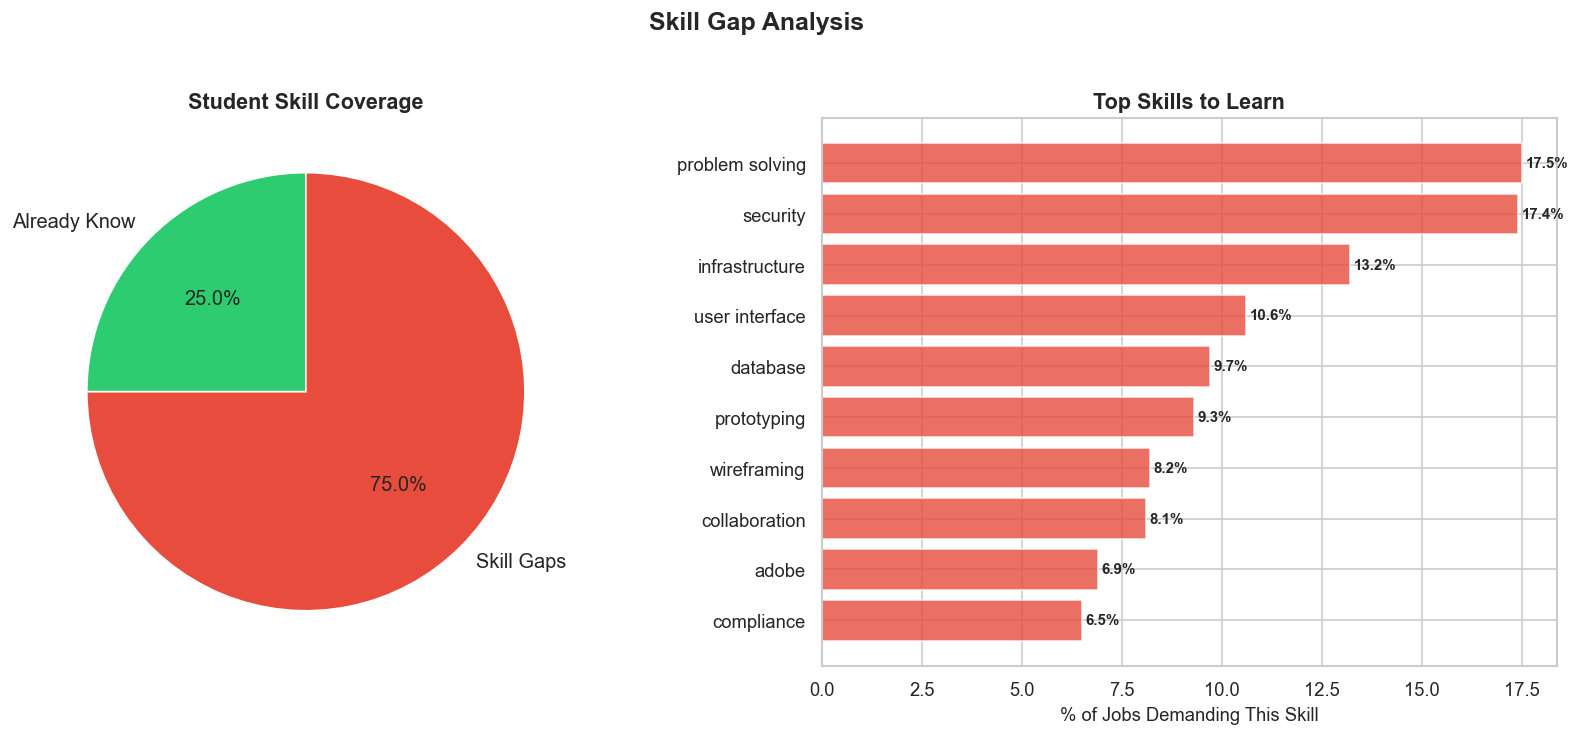

✅ Chart saved to: D:/Sinali/projects/job_market_intelligence_platform/outputs/skill_gap.png


In [7]:
# ── SKILL GAP VISUALIZATION ──────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── LEFT CHART: Known vs Gap ──────────────────
labels  = ['Already Know', 'Skill Gaps']
sizes   = [len(no_gaps), len(gaps)]
colors  = ['#2ecc71', '#e74c3c']

ax1.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
ax1.set_title('Student Skill Coverage', fontsize=13, fontweight='bold')

# ── RIGHT CHART: Top Gap Skills ───────────────
gap_skills  = [g[0] for g in gaps[:10]]
gap_pcts    = [g[1] for g in gaps[:10]]

bars = ax2.barh(
    gap_skills[::-1],
    gap_pcts[::-1],
    color='#e74c3c',
    alpha=0.8
)

for bar, val in zip(bars, gap_pcts[::-1]):
    ax2.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{val}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

ax2.set_title('Top Skills to Learn', fontsize=13, fontweight='bold')
ax2.set_xlabel('% of Jobs Demanding This Skill', fontsize=11)

plt.suptitle('Skill Gap Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()

chart_path = f'{OUTPUT_PATH}/skill_gap.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Chart saved to: {chart_path}")

In [8]:
# ── CAREER RECOMMENDATIONS ───────────────────
# Based on job market data we give career advice
# for each job cluster

recommendations = {
    'Software Development': {
        'top_skills'   : ['python', 'javascript', 'java', 'docker', 'git'],
        'learn_next'   : ['kubernetes', 'microservices', 'cloud', 'typescript'],
        'avg_salary'   : salary_by_cluster.get('Software Development', 0),
        'job_count'    : len(df[df['cluster_name'] == 'Software Development']),
        'advice'       : 'Focus on full stack skills and cloud deployment'
    },
    'Data & Analytics': {
        'top_skills'   : ['python', 'sql', 'data analysis', 'statistics', 'tableau'],
        'learn_next'   : ['machine learning', 'power bi', 'spark', 'deep learning'],
        'avg_salary'   : salary_by_cluster.get('Data & Analytics', 0),
        'job_count'    : len(df[df['cluster_name'] == 'Data & Analytics']),
        'advice'       : 'Master visualization tools and ML fundamentals'
    },
    'Network & Security': {
        'top_skills'   : ['network security', 'infrastructure', 'linux', 'firewall'],
        'learn_next'   : ['cloud security', 'ethical hacking', 'siem', 'compliance'],
        'avg_salary'   : salary_by_cluster.get('Network & Security', 0),
        'job_count'    : len(df[df['cluster_name'] == 'Network & Security']),
        'advice'       : 'Get certified in CompTIA Security+ or CEH'
    },
    'Design & UI/UX': {
        'top_skills'   : ['figma', 'wireframing', 'prototyping', 'adobe', 'user research'],
        'learn_next'   : ['motion design', 'design systems', 'html', 'css'],
        'avg_salary'   : salary_by_cluster.get('Design & UI/UX', 0),
        'job_count'    : len(df[df['cluster_name'] == 'Design & UI/UX']),
        'advice'       : 'Build a strong portfolio with real project case studies'
    },
    'Database & Systems': {
        'top_skills'   : ['sql', 'mysql', 'postgresql', 'oracle', 'database'],
        'learn_next'   : ['mongodb', 'redis', 'cloud databases', 'data modeling'],
        'avg_salary'   : salary_by_cluster.get('Database & Systems', 0),
        'job_count'    : len(df[df['cluster_name'] == 'Database & Systems']),
        'advice'       : 'Learn both SQL and NoSQL databases for versatility'
    },
    'Marketing & Architecture': {
        'top_skills'   : ['analytics', 'communication', 'reporting', 'project management'],
        'learn_next'   : ['digital marketing', 'seo', 'google analytics', 'crm'],
        'avg_salary'   : salary_by_cluster.get('Marketing & Architecture', 0),
        'job_count'    : len(df[df['cluster_name'] == 'Marketing & Architecture']),
        'advice'       : 'Combine technical and business communication skills'
    }
}

# ── PRINT RECOMMENDATIONS ─────────────────────
print("🎯 CAREER RECOMMENDATIONS BY CLUSTER:")
print("=" * 55)

for career, info in recommendations.items():
    print(f"\n💼 {career}")
    print(f"   Jobs Available  : {info['job_count']}")
    print(f"   Average Salary  : ${info['avg_salary']:,.0f}")
    print(f"   You Should Know : {', '.join(info['top_skills'])}")
    print(f"   Learn Next      : {', '.join(info['learn_next'])}")
    print(f"   Advice          : {info['advice']}")
    print(f"   {'-' * 50}")

🎯 CAREER RECOMMENDATIONS BY CLUSTER:

💼 Software Development
   Jobs Available  : 403
   Average Salary  : $82,129
   You Should Know : python, javascript, java, docker, git
   Learn Next      : kubernetes, microservices, cloud, typescript
   Advice          : Focus on full stack skills and cloud deployment
   --------------------------------------------------

💼 Data & Analytics
   Jobs Available  : 557
   Average Salary  : $82,959
   You Should Know : python, sql, data analysis, statistics, tableau
   Learn Next      : machine learning, power bi, spark, deep learning
   Advice          : Master visualization tools and ML fundamentals
   --------------------------------------------------

💼 Network & Security
   Jobs Available  : 480
   Average Salary  : $82,665
   You Should Know : network security, infrastructure, linux, firewall
   Learn Next      : cloud security, ethical hacking, siem, compliance
   Advice          : Get certified in CompTIA Security+ or CEH
   ------------------

In [9]:
# ── FINAL SUMMARY REPORT ─────────────────────

print("=" * 60)
print("   AI-POWERED JOB MARKET INTELLIGENCE REPORT")
print("   Sri Lanka — IT Job Market Analysis")
print("=" * 60)

print(f"""
📊 DATASET SUMMARY:
   Total IT Jobs Analyzed   : {len(df)}
   Unique Job Titles        : {df['title'].nunique()}
   Unique Companies         : {df['company'].nunique()}
   Countries Covered        : {df['country'].nunique()}

💰 SALARY INSIGHTS:
   Average Salary           : ${df['salary_avg'].mean():,.0f}
   Highest Paying Cluster   : {salary_by_cluster.index[0]} (${salary_by_cluster.iloc[0]:,.0f})
   Lowest Paying Cluster    : {salary_by_cluster.index[-1]} (${salary_by_cluster.iloc[-1]:,.0f})

🔥 TOP 5 MOST DEMANDED SKILLS:
   1. Problem Solving        (17.5% of jobs)
   2. Security               (17.4% of jobs)
   3. Communication          (16.4% of jobs)
   4. Infrastructure         (13.2% of jobs)
   5. Data Analysis          (11.8% of jobs)

🤖 MODEL RESULTS:
   TF-IDF Features          : 100 important terms
   K-Means Clusters         : 6 job categories
   LDA Topics               : 6 hidden themes

📁 JOB CLUSTERS FOUND:
""")

for cluster, count in df['cluster_name'].value_counts().items():
    pct = round(count / len(df) * 100, 1)
    bar = '█' * int(pct / 2)
    print(f"   {cluster:<30} {bar} {pct}%")

print(f"""
🎯 SKILL GAP SUMMARY:
   Skills Students Know     : {len(no_gaps)} / 20
   Skill Gaps Found         : {len(gaps)} / 20
   Top Skill to Learn       : {gaps[0][0]} ({gaps[0][1]}% of jobs)

📁 OUTPUT FILES SAVED:
   → outputs/top_skills.png
   → outputs/skill_categories.png
   → outputs/clusters.png
   → outputs/topics.png
   → outputs/salary_by_cluster.png
   → outputs/skill_gap.png

{"=" * 60}
   PROJECT COMPLETE! Ready for Frontend Development
{"=" * 60}
""")

   AI-POWERED JOB MARKET INTELLIGENCE REPORT
   Sri Lanka — IT Job Market Analysis

📊 DATASET SUMMARY:
   Total IT Jobs Analyzed   : 4301
   Unique Job Titles        : 62
   Unique Companies         : 884
   Countries Covered        : 216

💰 SALARY INSIGHTS:
   Average Salary           : $82,513
   Highest Paying Cluster   : Data & Analytics ($82,959)
   Lowest Paying Cluster    : Database & Systems ($82,058)

🔥 TOP 5 MOST DEMANDED SKILLS:
   1. Problem Solving        (17.5% of jobs)
   2. Security               (17.4% of jobs)
   3. Communication          (16.4% of jobs)
   4. Infrastructure         (13.2% of jobs)
   5. Data Analysis          (11.8% of jobs)

🤖 MODEL RESULTS:
   TF-IDF Features          : 100 important terms
   K-Means Clusters         : 6 job categories
   LDA Topics               : 6 hidden themes

📁 JOB CLUSTERS FOUND:

   Marketing & Architecture       █████████████████████ 42.2%
   Design & UI/UX                 █████████ 19.1%
   Data & Analytics               

In [10]:
import subprocess
import sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'streamlit'])
print("✅ Streamlit installed!")

✅ Streamlit installed!
